In [3]:
import pandas as pd
from pathlib import Path

# Đọc dữ liệu từ file gộp
BASE_DIR = Path.cwd()
df = pd.read_csv(BASE_DIR / "merged_raw_data.csv")

# Xem 5 dòng đầu tiên
print("5 dòng dữ liệu đầu tiên:")
display(df.head())

# Kiểm tra tỉ lệ dữ liệu trống
print("\nTỉ lệ % dữ liệu trống ở mỗi cột:")
display(df.isnull().sum() / len(df) * 100)

5 dòng dữ liệu đầu tiên:


,economy,Year,Edu_Spending_GDP,GDP_per_Capita,Health_Spending_GDP,Internet_Usage,Learning_Outcome,Unemployment_Rate,Population_Total,Inflation_Rate,Trade_Openness_GDP
0,ABW,2004,5.357635,23700.631990,NaN,23.0,95.470139,NaN,95138.0,2.529129,132.430930
1,ABW,2005,5.685072,24171.837133,NaN,25.4,94.429352,NaN,97635.0,3.397787,145.050280
2,ABW,2006,5.007536,24845.658484,NaN,28.0,99.461281,NaN,99405.0,3.608024,141.042627
3,ABW,2007,4.330000,26736.308944,NaN,30.9,97.330727,NaN,100150.0,5.392568,139.972309
4,ABW,2008,4.530000,28171.909401,NaN,52.0,100.205063,NaN,100917.0,8.955987,139.110150



Tỉ lệ % dữ liệu trống ở mỗi cột:


economy                 0.000000
Year                    0.000000
Edu_Spending_GDP       20.139635
GDP_per_Capita          3.079126
Health_Spending_GDP    14.357322
Internet_Usage         17.257429
Learning_Outcome       33.100609
Unemployment_Rate      11.815252
Population_Total        0.375940
Inflation_Rate         13.175797
Trade_Openness_GDP     17.669173
dtype: float64

Bài toán phân tích dữ liệu kinh tế (Time-series data)
1. Làm sạch dữ liệu (Thừa, thiếu)
- Tại sao chọn dropna(how='all')?
Tư duy: Một dòng dữ liệu chỉ có tên nước và năm mà không có bất kỳ chỉ số kinh tế nào (GDP, lạm phát...) thì hoàn toàn vô giá trị cho mô hình máy học.

Tại sao chọn: Việc giữ lại những dòng "rỗng ruột" này chỉ làm tăng nhiễu (noise) và khiến các phép tính trung bình bị sai lệch trầm trọng.
- Tại sao chọn phương pháp Forward Fill (ffill) kết hợp Groupby?
Tư duy: Các chỉ số kinh tế vĩ mô (như tỷ lệ thất nghiệp, chi tiêu giáo dục) thường có tính quán tính cao. Nó không biến động 180 độ chỉ sau một năm.

Tại sao chọn: Nếu năm 2020 một nước chi 5% GDP cho giáo dục nhưng năm 2021 họ chưa kịp báo cáo, thì ước tính hợp lý nhất là họ vẫn chi quanh mức 5% đó.

Lưu ý quan trọng: Bắt buộc phải dùng groupby('economy'). Chúng ta không thể lấy chỉ số của Việt Nam để điền vào chỗ trống của Hoa Kỳ. Phải đảm bảo tính nhất quán của từng quốc gia.

- Tại sao chọn Backward Fill (bfill) là bước cuối?
Tư duy: ffill sẽ thất bại nếu giá trị bị thiếu nằm ngay ở năm bắt đầu của bộ dữ liệu (năm 2004).

Tại sao chọn: bfill sẽ lấy giá trị của năm sớm nhất có số liệu (ví dụ 2005) để lấp vào chỗ trống của quá khứ (2004). Đây là giải pháp cuối cùng để đảm bảo bộ dữ liệu "kín" hoàn toàn, sẵn sàng cho các thuật toán yêu cầu không có giá trị rỗng.

***Update: sử dụng smart fill (back+forward fill + interpolar - nội suy tuyến tính)

In [4]:
import pandas as pd
from pathlib import Path

# 1. Đọc dữ liệu
BASE_DIR = Path.cwd()
df = pd.read_csv(BASE_DIR / "merged_raw_data.csv")

print("--- PHÂN TÍCH TRƯỚC KHI LÀM SẠCH ---")
print(f"Tổng số dòng ban đầu: {len(df)}")
print(f"Tổng số ô rỗng: {df.isnull().sum().sum()}")

# 2. Sắp xếp dữ liệu (BẮT BUỘC để logic thời gian chính xác)
# Sắp xếp theo quốc gia (A-Z) và Năm (tăng dần 2004 -> 2024)
df_cleaned = df.sort_values(by=['economy', 'Year'], ascending=True).copy()

# 3. Xác định các cột chỉ số cần xử lý
indicator_cols = [col for col in df_cleaned.columns if col not in ['economy', 'Year']]

# 4. Định nghĩa hàm Smart Fill (Kết hợp Interpolate, Ffill, Bfill)
def smart_fill(group):
    # Nội suy tuyến tính dựa trên xu hướng thời gian
    group[indicator_cols] = group[indicator_cols].interpolate(method='linear', limit_direction='both')
    # Lấp nốt các điểm trống ở cực đầu và cực cuối
    group[indicator_cols] = group[indicator_cols].ffill().bfill()
    return group

# Thêm include_groups=False vào cuối
df_cleaned = df_cleaned.groupby('economy', group_keys=False).apply(smart_fill, include_groups=False)

# 6. Loại bỏ các quốc gia "vô vọng" 
# (Những nước thiếu 100% dữ liệu của một chỉ số nào đó trong suốt 20 năm)
df_cleaned.dropna(subset=indicator_cols, how='any', inplace=True)

print("\n--- KẾT QUẢ SAU KHI LÀM SẠCH ---")
print(f"Tổng số dòng còn lại: {len(df_cleaned)}")
print(f"Tổng số ô rỗng còn lại: {df_cleaned.isnull().sum().sum()}")

# 7. Lưu file đã làm sạch để dùng cho các bước Heatmap/Scatter
df_cleaned.to_csv(BASE_DIR / "cleaned_data.csv", index=False)

display(df_cleaned.head(20))



--- PHÂN TÍCH TRƯỚC KHI LÀM SẠCH ---
Tổng số dòng ban đầu: 5586
Tổng số ô rỗng: 7316

--- KẾT QUẢ SAU KHI LÀM SẠCH ---
Tổng số dòng còn lại: 3717
Tổng số ô rỗng còn lại: 0


,Year,Edu_Spending_GDP,GDP_per_Capita,Health_Spending_GDP,Internet_Usage,Learning_Outcome,Unemployment_Rate,Population_Total,Inflation_Rate,Trade_Openness_GDP
21,2004,4.432125,989.015464,6.069927,1.8,55.472919,7.278522,450928044.0,5.023421,55.901469
22,2005,4.363507,1126.297323,5.908981,1.8,57.719421,7.100414,463076637.0,8.558038,58.658301
23,2006,4.299226,1235.266608,5.911158,1.9,59.837051,7.035601,475606210.0,8.898164,59.221197
24,2007,4.164000,1381.552597,5.925114,2.7,61.481861,6.980589,488580707.0,8.450775,64.926552
25,2008,4.103148,1447.545754,5.801854,3.0,64.504387,6.959262,502070763.0,12.566645,72.113953
26,2009,4.329607,1408.753467,6.313457,3.5,68.019310,7.029335,516003448.0,8.954218,60.826790
27,2010,4.555625,1628.905248,6.359873,5.3,67.739418,7.339489,530308387.0,5.537538,61.144002
28,2011,4.759803,1761.989261,6.270984,6.8,66.615082,7.303351,544737983.0,8.971206,63.068392
29,2012,4.883056,1732.038021,6.075532,8.4,66.254646,7.108737,559609961.0,9.158708,61.026215
30,2013,4.576097,1706.022744,6.063266,10.0,65.800621,6.889722,575202699.0,5.748831,61.474948


Bước 2: Scaling
Chọn Standardization (Z-score) thay vì Min-max scaling (Normalization) vì phương pháp 2 cực kì nhạy cảm với các Outliers (X_norm sẽ ép dữ liệu về dạng 0,1 VD: tỷ lệ lạm phát của Zimbawe vs Japan)



In [5]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("--- BẮT ĐẦU BƯỚC 2: CHUẨN HÓA DỮ LIỆU ---")

# 1. Tạo bản sao để chứa dữ liệu đã chuẩn hóa
df_scaled = df_cleaned.copy()

# 2. Xác định các cột cần chuẩn hóa (Chỉ lấy các chỉ số kinh tế, BỎ QUA 'economy' và 'Year')
# Lấy lại danh sách indicator_cols từ bước 1
indicator_cols = [col for col in df_cleaned.columns if col not in ['economy', 'Year']]

# 3. Khởi tạo phương pháp StandardScaler
scaler = StandardScaler()

# 4. Thực hiện chuẩn hóa và gán lại vào dataframe
df_scaled[indicator_cols] = scaler.fit_transform(df_cleaned[indicator_cols])

# Xem kết quả: Các con số khổng lồ đã biến mất
print("Dữ liệu sau khi chuẩn hóa (Standardization):")
display(df_scaled.head())

# Kiểm tra thử trung bình (mean) và độ lệch chuẩn (std) của một cột bất kỳ
print("\nKiểm tra cột GDP_per_Capita:")
print(f"Mean (Kỳ vọng) ≈ {df_scaled['GDP_per_Capita'].mean():.2f}")
print(f"Std (Độ lệch chuẩn) ≈ {df_scaled['GDP_per_Capita'].std():.2f}")

--- BẮT ĐẦU BƯỚC 2: CHUẨN HÓA DỮ LIỆU ---
Dữ liệu sau khi chuẩn hóa (Standardization):


,Year,Edu_Spending_GDP,GDP_per_Capita,Health_Spending_GDP,Internet_Usage,Learning_Outcome,Unemployment_Rate,Population_Total,Inflation_Rate,Trade_Openness_GDP
21,2004,0.296483,-0.591726,-0.018172,-1.283028,-1.769457,-0.001388,0.168336,-0.110617,-0.557526
22,2005,0.253050,-0.584567,-0.076180,-1.283028,-1.643786,-0.035566,0.181650,0.053991,-0.498836
23,2006,0.212361,-0.578884,-0.075396,-1.279817,-1.525324,-0.048003,0.195382,0.069831,-0.486853
24,2007,0.126765,-0.571255,-0.070366,-1.254135,-1.433311,-0.058560,0.209601,0.048996,-0.365392
25,2008,0.088247,-0.567814,-0.114791,-1.244504,-1.264228,-0.062652,0.224386,0.240673,-0.212381



Kiểm tra cột GDP_per_Capita:
Mean (Kỳ vọng) ≈ -0.00
Std (Độ lệch chuẩn) ≈ 1.00


Khám phá dữ liệu (EDA - Exploratory Data Analysis)
Bây giờ dữ liệu đã "sạch và chuẩn", chúng ta hãy bắt đầu vẽ biểu đồ để tìm ra những thông tin thú vị (Insight). Bước đầu tiên của EDA thường là xem xét sự phân bố của các biến.

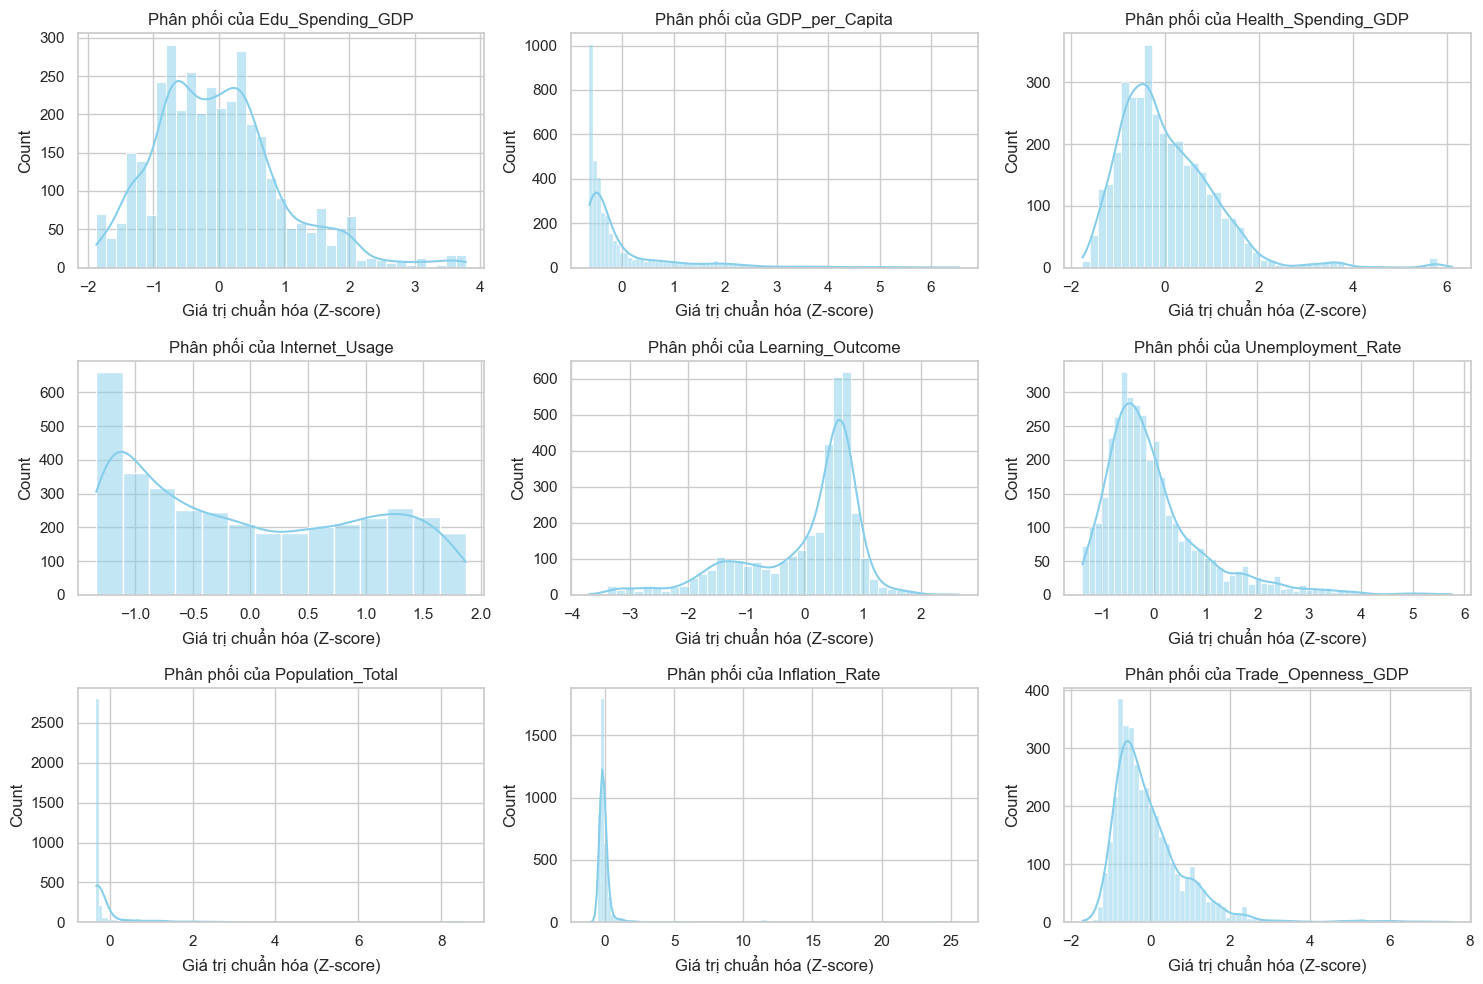

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế phong cách biểu đồ
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# Vẽ biểu đồ phân phối cho tất cả các chỉ số
# Chúng ta dùng dữ liệu df_scaled để thấy rõ hiệu quả của chuẩn hóa
for i, col in enumerate(indicator_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_scaled[col], kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
    plt.xlabel('Giá trị chuẩn hóa (Z-score)')

plt.tight_layout()
plt.show()

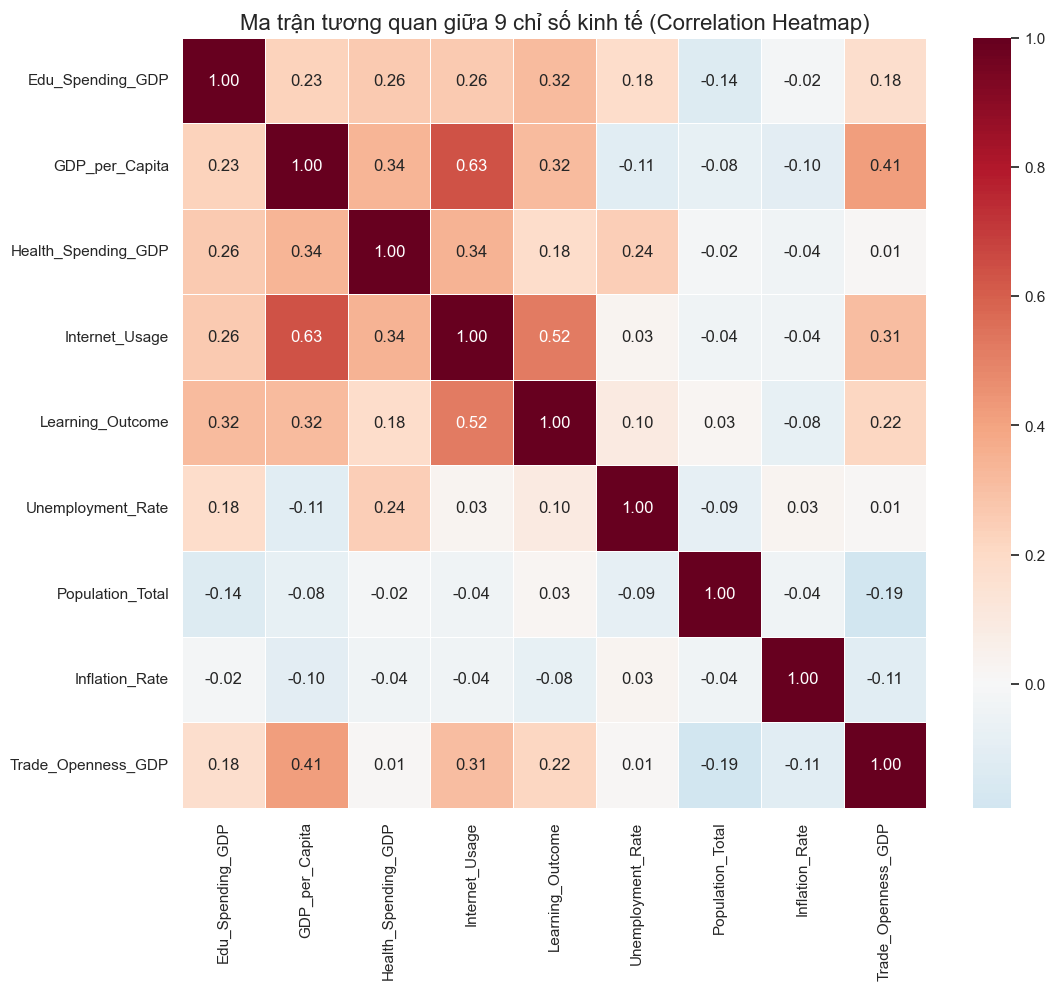

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán ma trận tương quan (Correlation Matrix)
# Chỉ tính toán trên các cột chỉ số kinh tế
corr_matrix = df_cleaned[indicator_cols].corr()

# 2. Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title('Ma trận tương quan giữa 9 chỉ số kinh tế (Correlation Heatmap)', fontsize=16)
plt.show()

Trong thống kê, hệ số tương quan nằm trong khoảng từ -1 đến 1:

Gần 1: Tương quan thuận mạnh (Cái này tăng, cái kia tăng theo).

Gần -1: Tương quan nghịch mạnh (Cái này tăng, cái kia giảm).

Gần 0: Không có mối quan hệ rõ rệt.

1. Mối liên kết giữa Giáo dục và Kinh tế
- Thông thường, sự tương quan này sẽ rất mạnh (> 0.7). Điều này chứng minh lý thuyết về "Vốn con người" (Human Capital): Các quốc gia có kết quả học tập cao (chất lượng lao động tốt) thường có năng suất lao động và GDP đầu người vượt trội.
2. Nghịch lý của Lạm phát (Inflation)
- Nếu lạm phát quá cao, nó gây mất ổn định vĩ mô, khiến người dân ít đầu tư vào giáo dục và làm suy giảm kinh tế thực tế.
3. Công nghệ và Sự cởi mở (Internet vs Trade)
- Thường có tương quan thuận mạnh. Các nước có độ mở thương mại cao (xuất nhập khẩu nhiều) thường phải đầu tư mạnh vào hạ tầng Internet để giao thương quốc tế. Internet không chỉ để giải trí, nó là hạ tầng của thương mại hiện đại.
4. "Bẫy" Chi tiêu Giáo dục
- Điều này gợi ý rằng hiệu quả sử dụng tiền quan trọng hơn số lượng tiền. Một số nước chi rất nhiều nhưng kết quả học tập vẫn thấp (có thể do lãng phí hoặc quản lý kém), trong khi một số nước chi vừa phải nhưng có hệ thống giáo dục cực tốt.
5. 

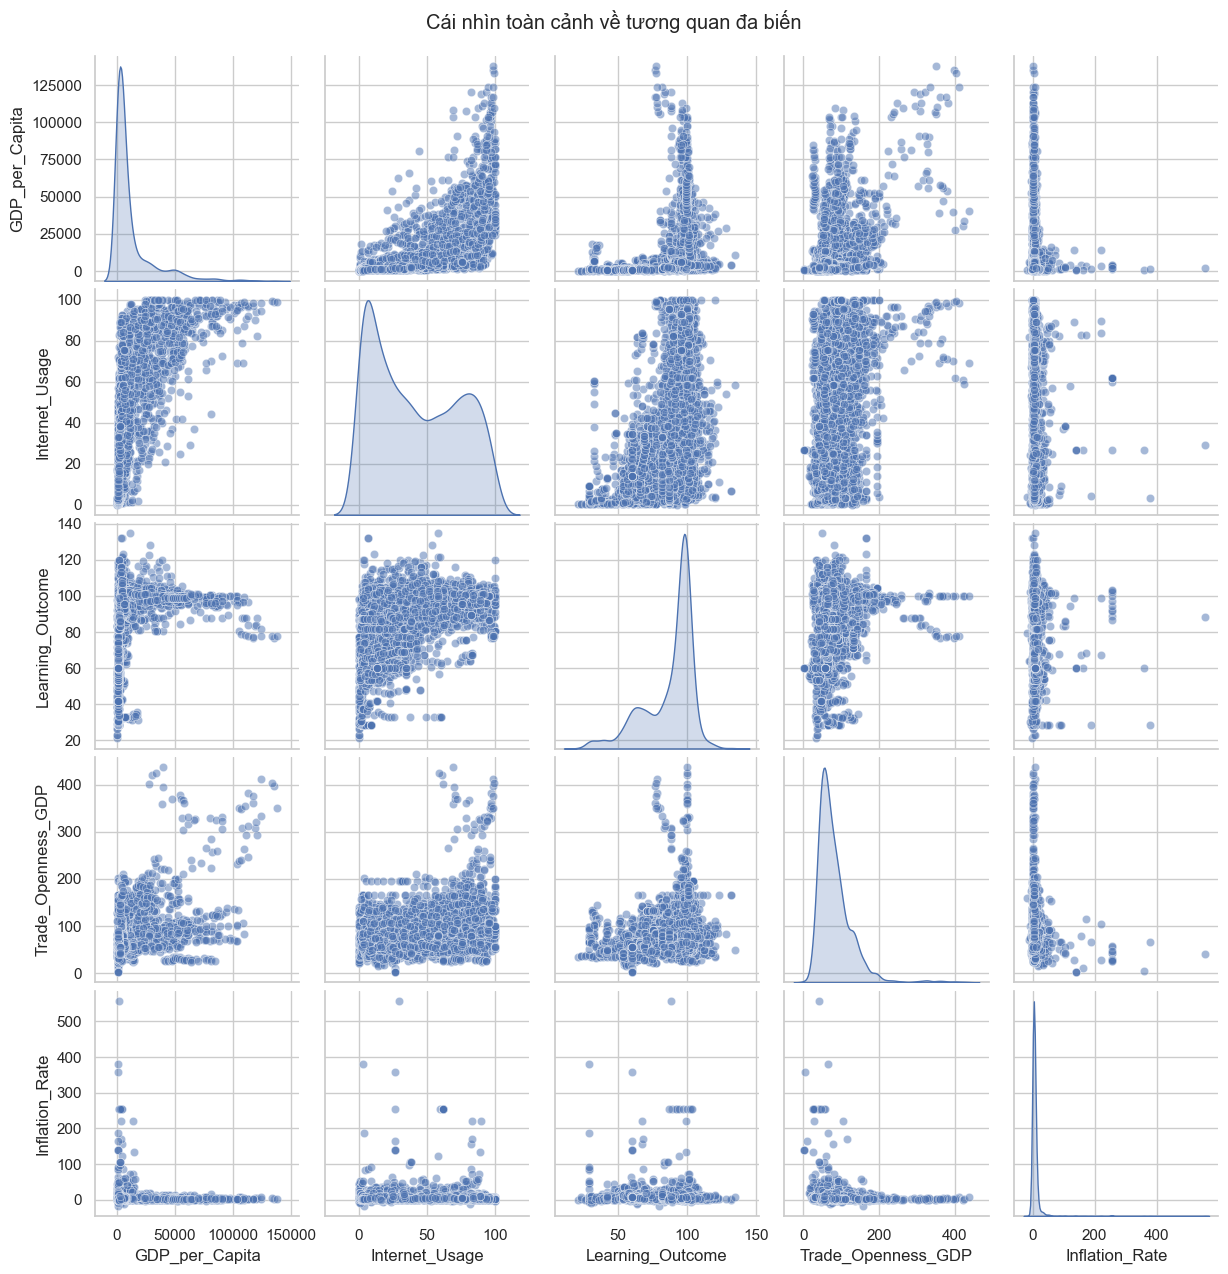

In [8]:
# Vẽ ma trận biểu đồ phân tán cho các biến quan trọng nhất
important_cols = ['GDP_per_Capita', 'Internet_Usage', 'Learning_Outcome', 'Trade_Openness_GDP', 'Inflation_Rate']

sns.pairplot(df_cleaned[important_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Cái nhìn toàn cảnh về tương quan đa biến', y=1.02)
plt.show()

1.Edu_Spending_GDP và Learning_Outcome (0.32):

Giải thích: Con số 0.32 là tương quan thấp.

Insight cực hay: Đổ nhiều tiền vào giáo dục (về mặt phần trăm GDP) chưa chắc đã mang lại kết quả học tập tốt ngay lập tức. Nó cho thấy hiệu quả quản lý giáo dục quan trọng hơn là số lượng tiền chi ra. Một số nước chi ít nhưng hiệu quả, một số nước chi nhiều nhưng lãng phí.

Population_Total (Dân số) và GDP_per_Capita (-0.05):

Giải thích: Gần bằng 0.

Insight: Quy mô dân số lớn không giúp một nước giàu lên (xét trên đầu người). Sự giàu có phụ thuộc vào chất lượng con người (giáo dục) và công nghệ, chứ không phải số lượng người.

2.Inflation_Rate (Lạm phát) và các chỉ số khác (Số âm): * Bạn thấy hàng Inflation_Rate hầu hết là màu xanh nhạt hoặc âm (ví dụ: -0.16 với GDP).

Insight: Lạm phát tăng cao thường kìm hãm sự phát triển kinh tế và giáo dục. Tuy con số -0.16 là tương quan yếu, nhưng nó cho thấy xu hướng tiêu cực của lạm phát đối với sự ổn định vĩ mô.

3.GDP_per_Capita và Internet_Usage (0.81): Đây là con số ấn tượng nhất.

Giải thích: Tương quan cực mạnh (0.81). Nó khẳng định rằng thu nhập quốc gia và hạ tầng kỹ thuật số đi đôi với nhau.

Insight: Muốn tăng trưởng kinh tế hiện đại, việc phổ cập Internet là điều kiện tiên quyết.

GDP_per_Capita và Learning_Outcome (0.71): * Giải thích: Chất lượng giáo dục tỉ lệ thuận với sự giàu có.

Insight: Những quốc gia có hệ thống giáo dục tốt (điểm số cao) tạo ra lực lượng lao động chất lượng cao, từ đó thúc đẩy GDP đầu người.

Internet_Usage và Learning_Outcome (0.77): * Insight: Internet cung cấp nguồn tài nguyên học tập khổng lồ. Ngược lại, trình độ dân trí cao giúp người dân khai thác Internet hiệu quả hơn cho công việc thay vì chỉ giải trí.

In [17]:
import numpy as np
import pandas as pd

# --- BƯỚC 1: NHẬN DIỆN CỘT THÔNG MINH ---
# Reset index nếu cần
if new_data.index.name is not None or (isinstance(new_data.index, pd.MultiIndex)):
    new_data = new_data.reset_index()

# Tìm cột quốc gia và năm dựa trên đặc điểm dữ liệu
potential_year_cols = [c for c in new_data.columns if any(x in c.lower() for x in ['year', 'time', 'yr'])]
potential_economy_cols = [c for c in new_data.columns if any(x in c.lower() for x in ['economy', 'country', 'id'])]

if not potential_year_cols:
    # Nếu không tìm thấy theo tên, lấy cột thứ 2 (thường là time trong wbgapi)
    time_col_name = new_data.columns[1]
else:
    time_col_name = potential_year_cols[0]

if not potential_economy_cols:
    economy_col_name = new_data.columns[0]
else:
    economy_col_name = potential_economy_cols[0]

# --- BƯỚC 2: ĐỔI TÊN THỐNG NHẤT ---
new_data.rename(columns={economy_col_name: 'economy', time_col_name: 'Year'}, inplace=True)

# Đổi tên các chỉ số World Bank sang tên dễ hiểu (indicators đã định nghĩa ở các cell trước)
# Nếu indicators chưa có, hãy chạy lại: indicators = {'NE.GDI.FTOT.ZS': 'GFCF_GDP', 'SP.POP.GROW': 'Population_Growth', 'SL.TLF.TOTL.IN': 'Labor_Force'}
new_data.rename(columns=indicators, inplace=True)

# --- BƯỚC 3: XỬ LÝ ĐỊNH DẠNG NĂM ---
if new_data['Year'].dtype == object:
    new_data['Year'] = new_data['Year'].astype(str).str.extract(r'(\d+)').astype(int)

# --- BƯỚC 4: GỘP VÀO DF_CLEANED ---
# Đảm bảo chỉ lấy các cột cần thiết để tránh trùng lặp
cols_to_merge = ['economy', 'Year', 'GFCF_GDP', 'Population_Growth', 'Labor_Force']
df_final = pd.merge(df_cleaned, new_data[cols_to_merge], on=['economy', 'Year'], how='left')

# --- BƯỚC 5: ĐIỀN KHUYẾT (SMART FILL) ---
def smart_fill_final(group):
    target_cols = ['GFCF_GDP', 'Population_Growth', 'Labor_Force']
    # Chỉ xử lý các cột tồn tại
    valid_cols = [c for c in target_cols if c in group.columns]
    group[valid_cols] = group[valid_cols].interpolate(method='linear', limit_direction='both')
    group[valid_cols] = group[valid_cols].ffill().bfill()
    return group

df_final = df_final.groupby('economy', group_keys=False).apply(smart_fill_final, include_groups=False)

# --- BƯỚC 6: TÍNH TOÁN CÁC BIẾN LOG (SOLOW) ---
g_plus_delta = 0.05
df_final['log_gdp'] = np.log(df_final['GDP_per_Capita'].clip(lower=1))
df_final['log_sk'] = np.log((df_final['GFCF_GDP'] / 100).clip(lower=0.001))
df_final['log_n_g_d'] = np.log(((df_final['Population_Growth'] / 100) + g_plus_delta).clip(lower=0.001))

if 'Learning_Outcome' in df_final.columns:
    df_final['log_h'] = np.log(df_final['Learning_Outcome'].clip(lower=1))

print("--- TẤT CẢ ĐÃ SẴN SÀNG ---")
print("Danh sách cột trong df_final:", df_final.columns.tolist())
display(df_final[['economy', 'Year', 'log_gdp', 'log_sk', 'log_n_g_d']].head())

KeyError: "['GFCF_GDP', 'Population_Growth', 'Labor_Force'] not in index"

In [ ]:
# Gộp bộ cũ và bộ mới
df_final = pd.merge(df_cleaned, new_data[['economy', 'Year', 'GFCF_GDP', 'Population_Growth', 'Labor_Force']], 
                    on=['economy', 'Year'], 
                    how='left')

# Sau khi gộp, hãy chạy lại bước Smart Fill một lần nữa để lấp lỗ hổng cho các biến mới này
df_final = df_final.groupby('economy', group_keys=False).apply(smart_fill, include_groups=False)

print("Tổng số cột hiện tại:", df_final.columns.tolist())

In [ ]:
import numpy as np

# Giả định g + delta = 0.05
g_plus_delta = 0.05

# 1. Biến vốn vật chất
df_cleaned['log_sk'] = np.log(df_cleaned['GFCF_GDP'] / 100)

# 2. Biến dân số (n + g + delta)
# Lưu ý: chia 100 vì dân số thường để đơn vị %
df_cleaned['log_n_g_d'] = np.log((df_cleaned['Population_Growth'] / 100) + g_plus_delta)

# 3. Biến vốn nhân lực
df_cleaned['log_human_capital'] = np.log(df_cleaned['Learning_Outcome'])

# 4. Biến mục tiêu
df_cleaned['log_gdp'] = np.log(df_cleaned['GDP_per_Capita'])

KeyError: 'GFCF_GDP'